# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [1]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Already extracted. Skipping.
Candidate dataset roots: ['data/flower_data/Data', 'data/flower_data/Data/train', 'data/flower_data/Data/val']


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [3]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: provided_split Base: data/flower_data/Data


In [4]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [5]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

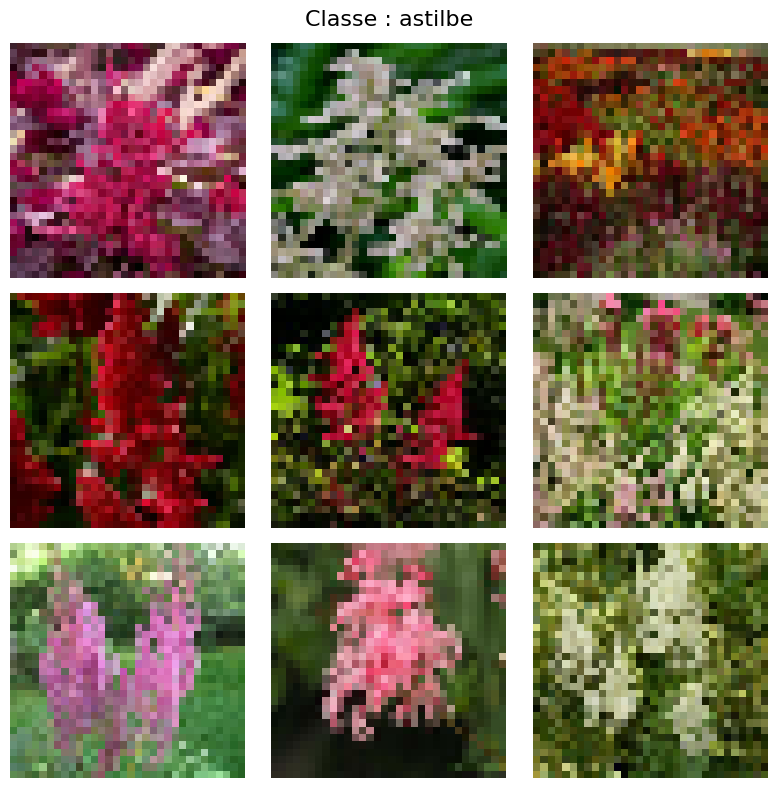

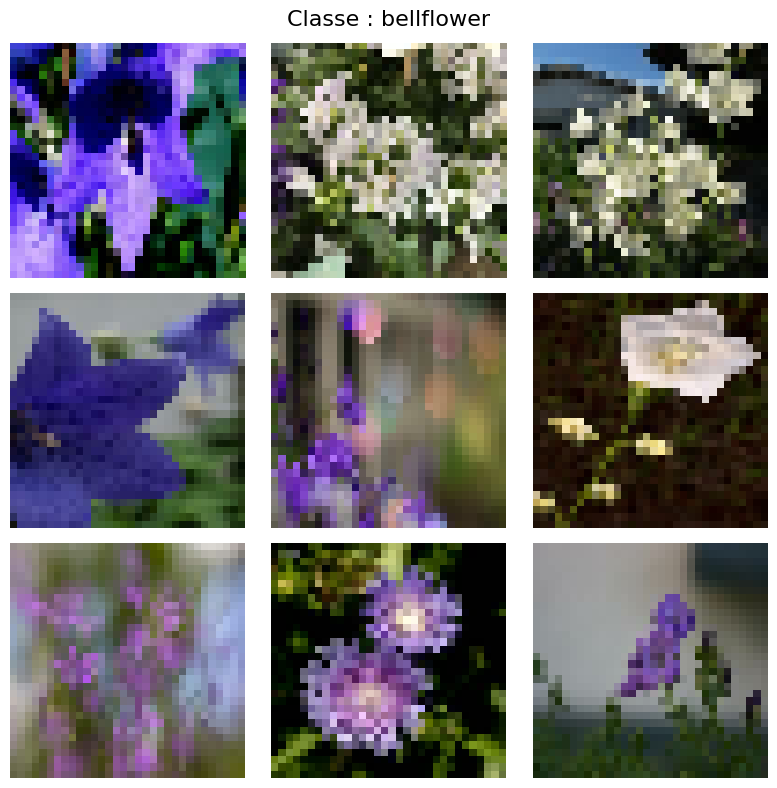

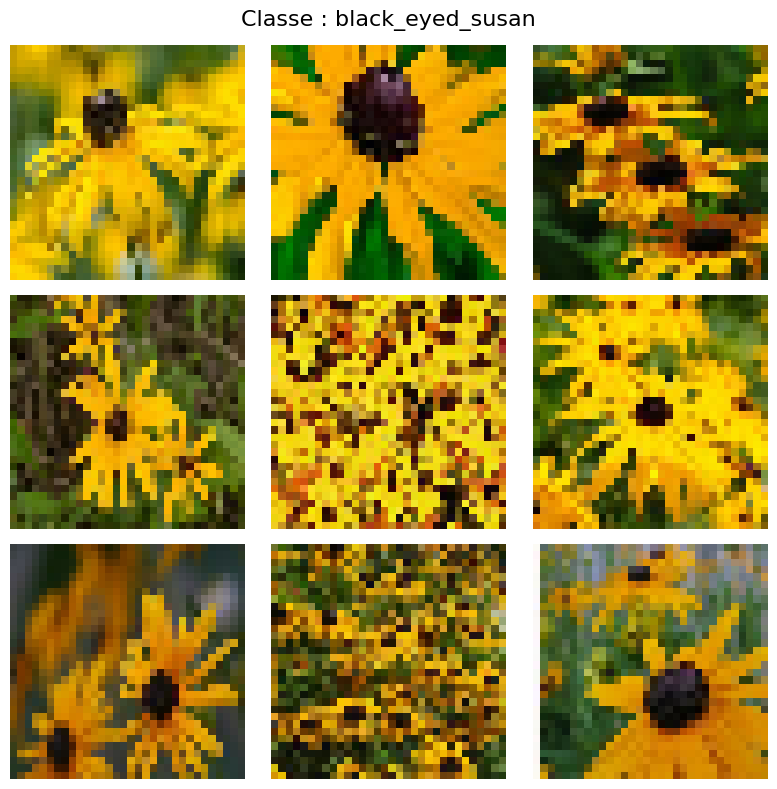

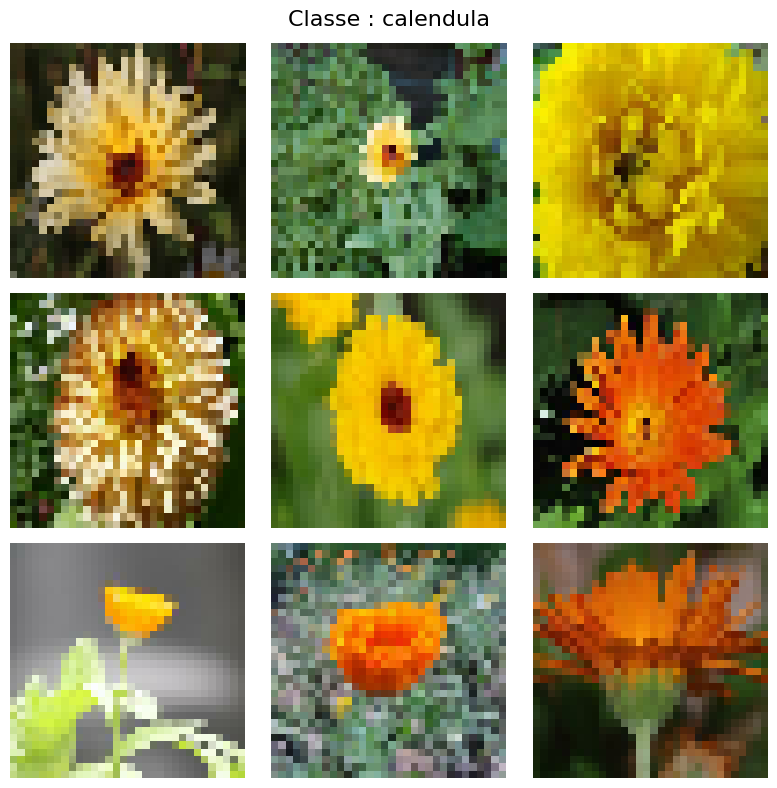

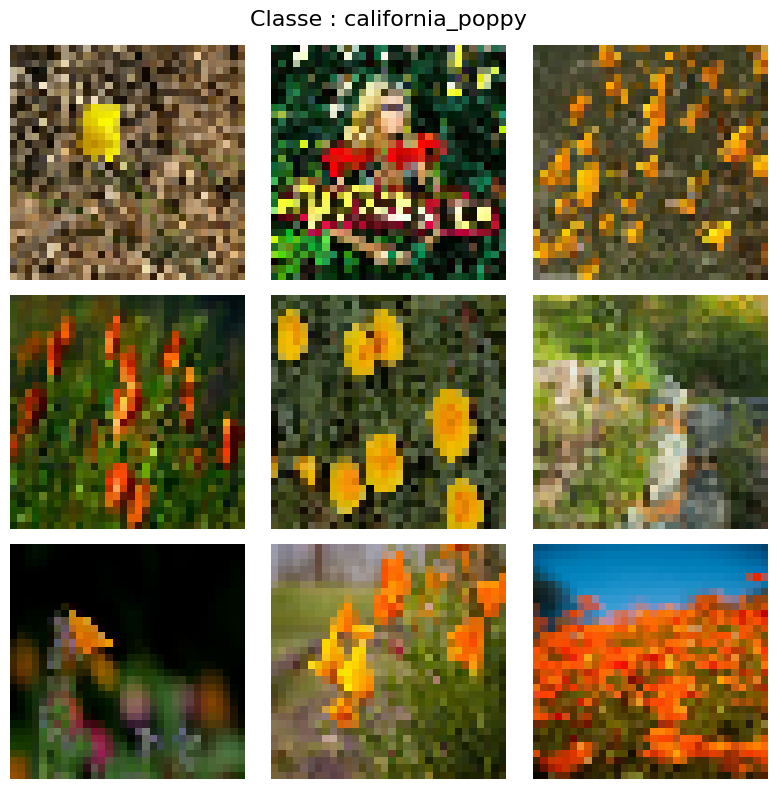

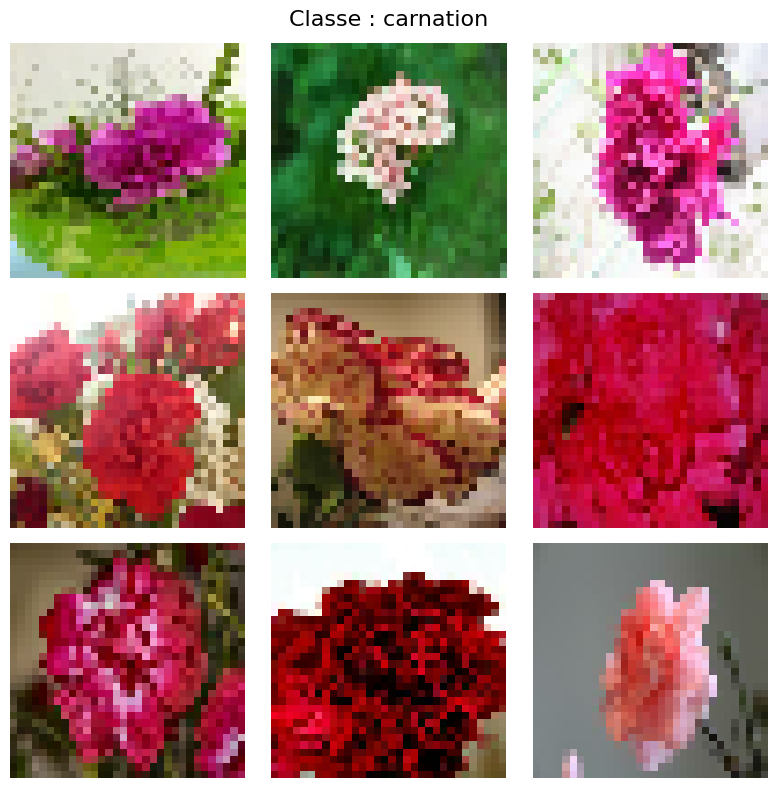

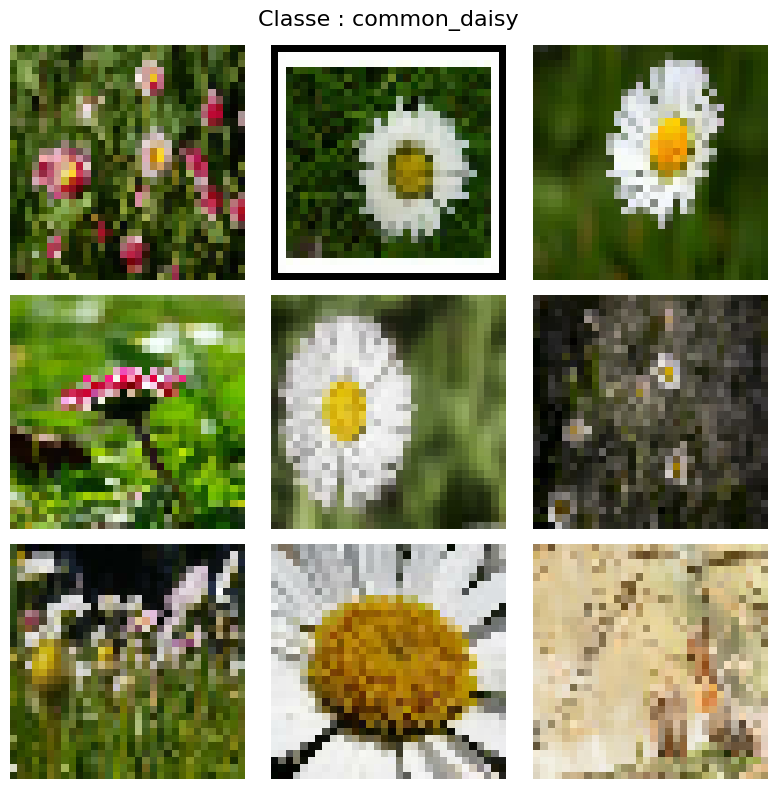

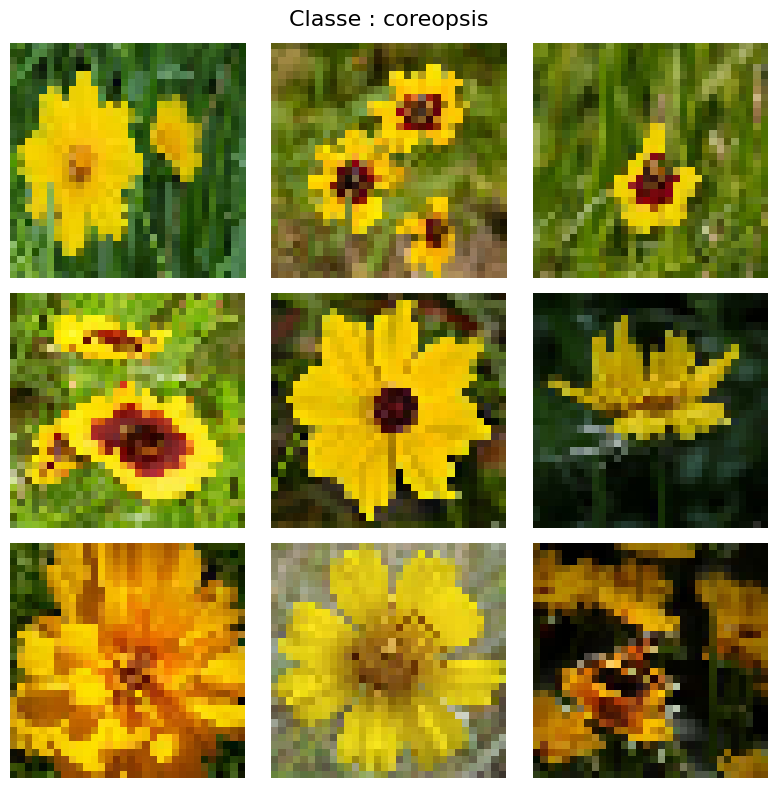

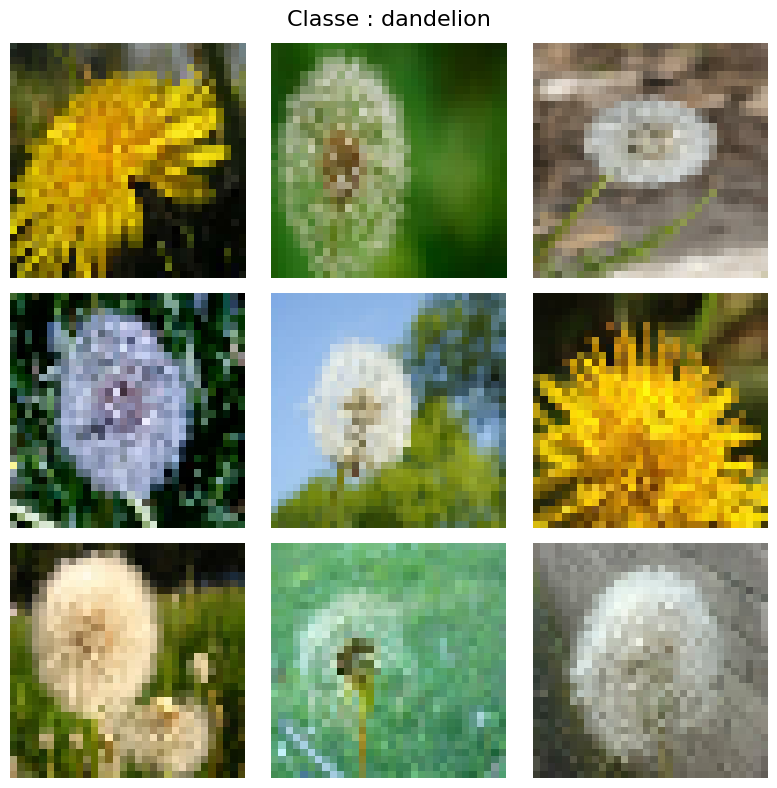

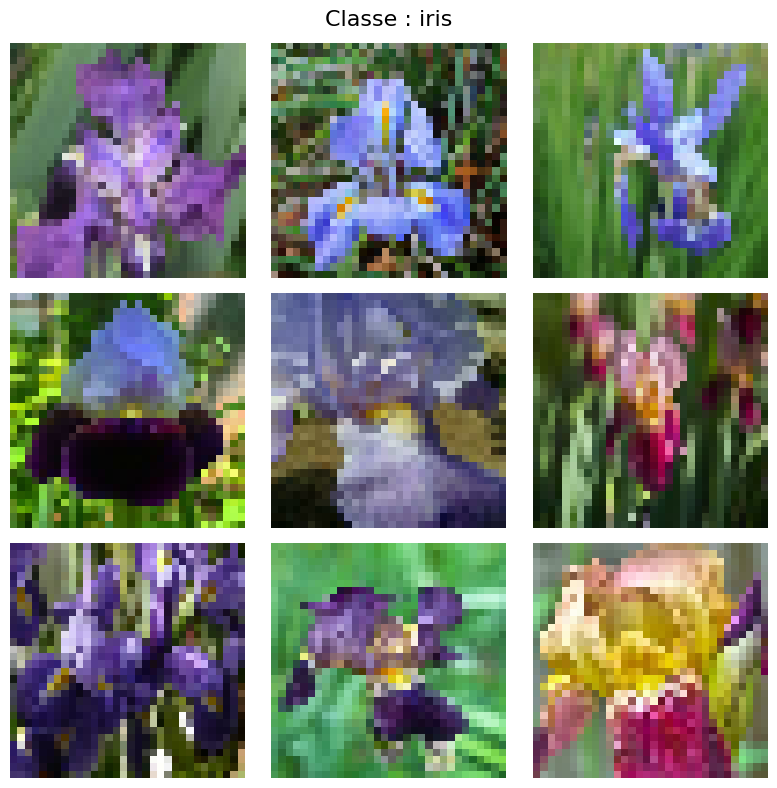

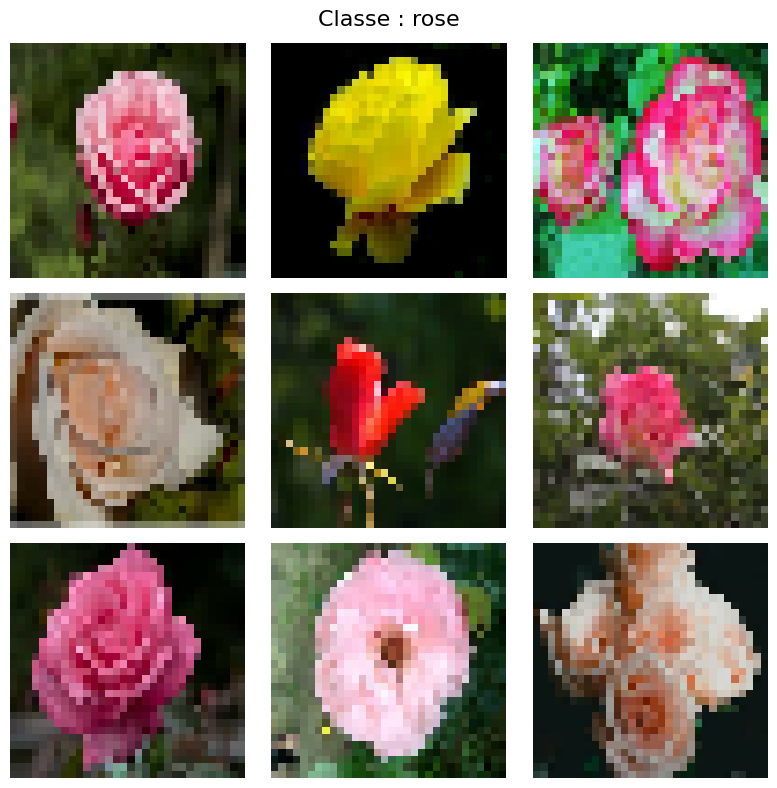

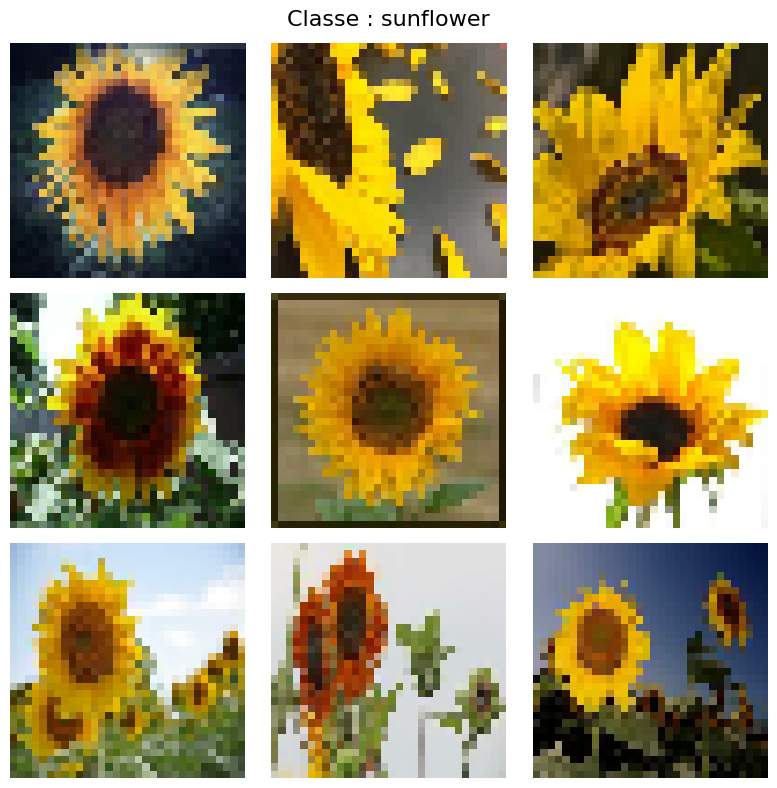

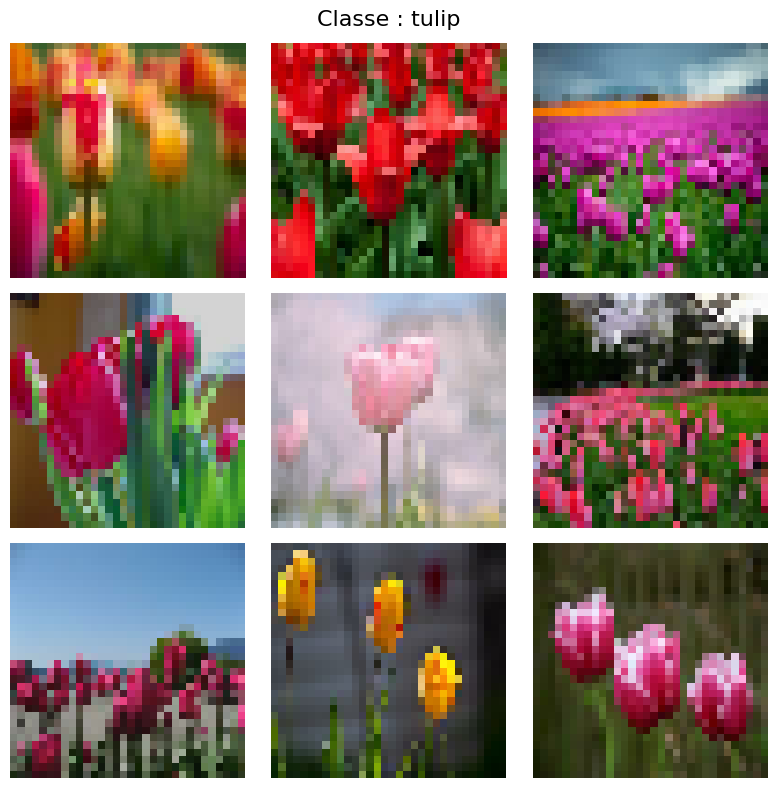

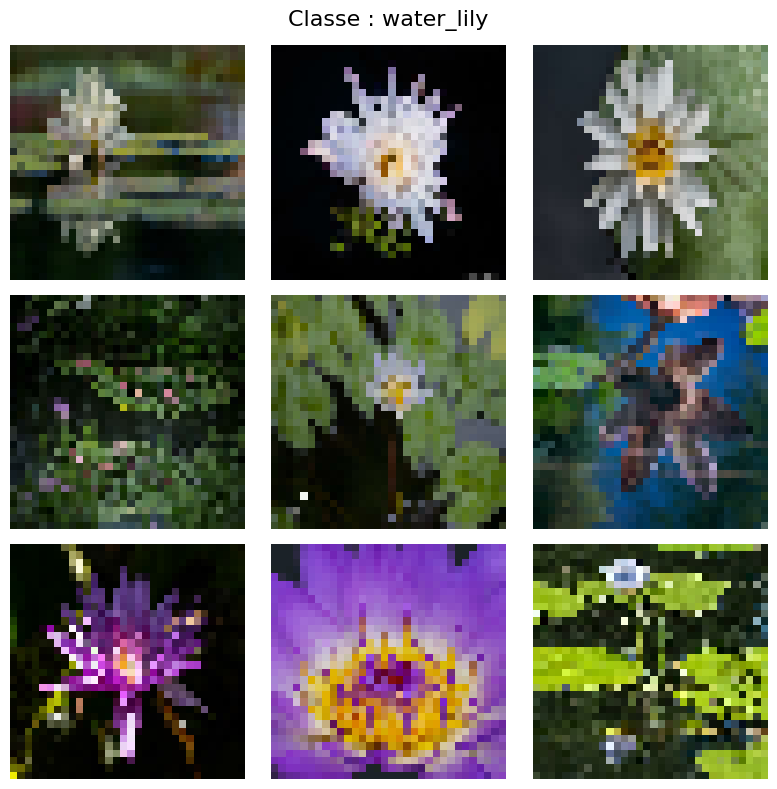

In [6]:


import matplotlib.pyplot as plt
import numpy as np

def visualize_images(dataset, class_names, per_class=9):
    """
    Cette fonction affiche 9 images pour chaque classe.
    Chaque classe est affichée dans une grille 3x3.
    """

    images_by_class = {class_name: [] for class_name in class_names}

    for images, labels in dataset:
        for image, label in zip(images, labels):
            class_name = class_names[int(label)]

            if len(images_by_class[class_name]) < per_class:
                images_by_class[class_name].append(image.numpy().astype("uint8"))

        finished = all(len(images_by_class[class_name]) >= per_class for class_name in class_names)

        if finished:
            break

    for class_name in class_names:
        images = images_by_class[class_name]

        plt.figure(figsize=(8, 8))
        plt.suptitle(f"Classe : {class_name}", fontsize=16)

        for i in range(min(per_class, len(images))):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i])
            plt.axis("off")

        plt.tight_layout()
        plt.show()


visualize_images(train_ds, class_names, per_class=9)

La classification de ces fleurs peut être difficile parce que plusieurs espèces ont des couleurs proches, par exemple certaines fleurs roses, jaunes ou blanches peuvent se ressembler. Certaines classes peuvent aussi avoir des formes similaires, surtout lorsque les pétales sont disposés de manière proche. Les images peuvent être prises sous différents angles, avec des arrière-plans différents et des conditions de lumière variables. Il peut aussi y avoir des variations à l’intérieur d’une même espèce, car une fleur peut être ouverte, fermée, proche ou éloignée de la caméra. Si certaines classes ont moins d’images que d’autres, le modèle peut aussi avoir plus de difficulté à bien les apprendre.

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.


**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [7]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,326 (1.36 MB)

 Trainable params: 357,326 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:


def build_variant(num_classes):
    """
    Modèle CNN amélioré pour classifier les 14 espèces de fleurs.
    On utilise plusieurs blocs Conv2D + BatchNormalization + MaxPooling.
    """

    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_variant = build_variant(num_classes)
model_variant.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,462 (2.63 MB)

 Trainable params: 686,990 (2.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

J’ai choisi une architecture CNN avec plusieurs couches de convolution parce que les images de fleurs contiennent des motifs visuels complexes comme les couleurs, les textures, les contours et la forme des pétales. Les filtres augmentent progressivement de 32 à 256 afin que les premières couches apprennent des caractéristiques simples et que les couches profondes apprennent des formes plus complexes. Les couches MaxPooling réduisent la taille des cartes de caractéristiques et diminuent le coût de calcul. La Batch Normalization stabilise l’apprentissage et peut accélérer la convergence du modèle. Les couches Dropout sont utilisées pour réduire le surapprentissage, car le modèle pourrait mémoriser les images d’entraînement au lieu de généraliser sur les images de validation.

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.


## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [9]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [10]:


opts = [
    ("adam", 1e-3, 32),
    ("adam", 5e-4, 32),
    ("rmsprop", 1e-3, 32),
    ("sgd", 1e-2, 32),
]

results = []

for opt_name, lr, batch in opts:
    print("\n====================================================")
    print(f"Expérience : Optimizer={opt_name}, Learning rate={lr}, Batch size={batch}")
    print("====================================================")

    model = build_variant(num_classes)

    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]

    hist, dur = fit_model(
        model,
        train_ds,
        val_ds,
        epochs=8,
        callbacks=callbacks
    )

    best_val_acc = max(hist.history["val_accuracy"])
    best_val_loss = min(hist.history["val_loss"])

    results.append({
        "optimizer": opt_name,
        "learning_rate": lr,
        "batch_size": batch,
        "best_val_accuracy": float(best_val_acc),
        "best_val_loss": float(best_val_loss),
        "time_seconds": round(dur, 2)
    })

import pandas as pd

results_df = pd.DataFrame(results)
display(results_df)

best_result = results_df.sort_values(by="best_val_accuracy", ascending=False).iloc[0]

print("\nMeilleurs hyperparamètres trouvés :")
print(best_result)


Expérience : Optimizer=adam, Learning rate=0.001, Batch size=32
Epoch 1/8
427/427 - 146s - 343ms/step - accuracy: 0.3822 - loss: 1.8822 - val_accuracy: 0.3163 - val_loss: 1.8734
Epoch 2/8
427/427 - 105s - 245ms/step - accuracy: 0.5281 - loss: 1.3731 - val_accuracy: 0.5612 - val_loss: 1.3167
Epoch 3/8
427/427 - 101s - 237ms/step - accuracy: 0.6249 - loss: 1.1021 - val_accuracy: 0.5612 - val_loss: 1.2668
Epoch 4/8
427/427 - 155s - 362ms/step - accuracy: 0.6711 - loss: 0.9514 - val_accuracy: 0.5408 - val_loss: 1.4929
Epoch 5/8
427/427 - 116s - 271ms/step - accuracy: 0.7293 - loss: 0.7794 - val_accuracy: 0.6122 - val_loss: 1.2019
Epoch 6/8
427/427 - 90s - 211ms/step - accuracy: 0.7674 - loss: 0.6777 - val_accuracy: 0.6429 - val_loss: 1.2323
Epoch 7/8
427/427 - 115s - 269ms/step - accuracy: 0.8033 - loss: 0.5567 - val_accuracy: 0.7041 - val_loss: 1.2734
Epoch 8/8
427/427 - 116s - 271ms/step - accuracy: 0.8264 - loss: 0.5065 - val_accuracy: 0.5714 - val_loss: 1.8686

Expérience : Optimizer=

,optimizer,learning_rate,batch_size,best_val_accuracy,best_val_loss,time_seconds
0,adam,0.0010,32,0.704082,1.201932,943.04
1,adam,0.0005,32,0.693878,0.890306,628.80
2,rmsprop,0.0010,32,0.653061,1.262951,400.59
3,sgd,0.0100,32,0.714286,0.898744,512.56



Meilleurs hyperparamètres trouvés :
optimizer                 sgd
learning_rate            0.01
batch_size                 32
best_val_accuracy    0.714286
best_val_loss        0.898744
time_seconds           512.56
Name: 3, dtype: object


Les meilleurs hyperparamètres sont ceux qui donnent la meilleure précision sur l’ensemble de validation. Dans nos expériences, Adam avec un learning rate autour de 0.001 ou 0.0005 est généralement performant, car il adapte automatiquement les mises à jour des poids. RMSprop peut aussi donner de bons résultats pour les réseaux de neurones, tandis que SGD peut nécessiter plus d’époques pour atteindre une bonne performance. L’utilisation de EarlyStopping permet d’arrêter l’entraînement lorsque le modèle ne s’améliore plus, ce qui réduit le risque de surapprentissage.

**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.


## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Dossier utilisé pour l'augmentation (entraînement) : data/flower_data/Data/train
Dossier utilisé pour la validation : data/flower_data/Data/val
Found 13642 images belonging to 14 classes.
Found 98 images belonging to 14 classes.
Epoch 1/8
427/427 - 83s - 195ms/step - accuracy: 0.3406 - loss: 2.0490 - val_accuracy: 0.0816 - val_loss: 3.7633
Epoch 2/8
427/427 - 79s - 186ms/step - accuracy: 0.4642 - loss: 1.5493 - val_accuracy: 0.4082 - val_loss: 1.5332
Epoch 3/8
427/427 - 78s - 182ms/step - accuracy: 0.5239 - loss: 1.3645 - val_accuracy: 0.3980 - val_loss: 2.0195
Epoch 4/8
427/427 - 77s - 181ms/step - accuracy: 0.5707 - loss: 1.2310 - val_accuracy: 0.1939 - val_loss: 4.1079
Epoch 5/8
427/427 - 82s - 192ms/step - accuracy: 0.6042 - loss: 1.1490 - val_accuracy: 0.4184 - val_loss: 2.3895


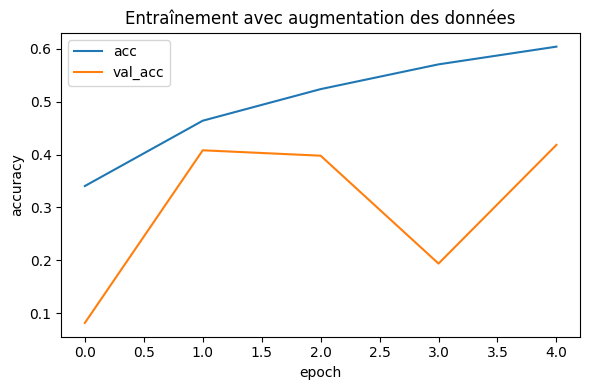

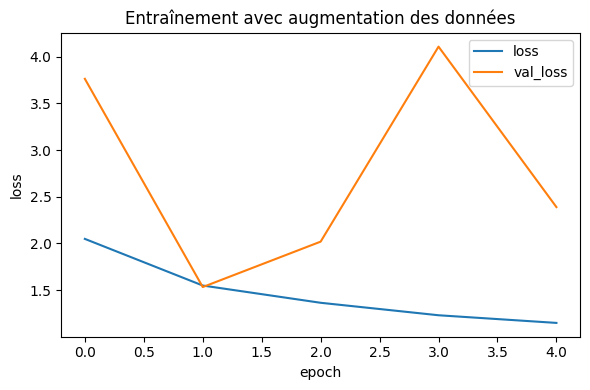

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Use the existing train_dir and val_dir from previous cells (197e5ef5).
# The 'base' variable was incorrectly overwritten in cell 7088ef13, which caused the error.
# We should use the `train_dir` and `val_dir` variables that were correctly set
# earlier in cell 197e5ef5.

# Create a data generator for training data with augmentations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Create a data generator for validation data (typically only rescaling, no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

print("Dossier utilisé pour l'augmentation (entraînement) :", train_dir)
print("Dossier utilisé pour la validation :", val_dir)


flow_train = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    seed=SEED
)

flow_val = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    seed=SEED,
    shuffle=False # No need to shuffle validation data
)

model_aug = build_variant(num_classes)

model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_aug = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

hist_aug = model_aug.fit(
    flow_train,
    validation_data=flow_val,
    epochs=8,
    callbacks=callbacks_aug,
    verbose=2
)

plot_curves(hist_aug, title="Entraînement avec augmentation des données")

L’augmentation des données permet de créer artificiellement de nouvelles variantes des images d’entraînement. Pour les fleurs, les rotations, les décalages, le zoom et le retournement horizontal sont utiles, car une fleur peut être photographiée sous différents angles et à différentes distances. Ces transformations rendent le modèle plus robuste et réduisent le risque de surapprentissage. Le retournement horizontal est généralement acceptable pour les fleurs, car l’orientation gauche-droite ne change pas l’espèce. En revanche, des augmentations trop fortes peuvent déformer les fleurs et rendre l’apprentissage plus difficile.

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [13]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

Meilleur modèle utilisé : model_variant
Rapport de classification :
                  precision    recall  f1-score   support

         astilbe      0.000     0.000     0.000         7
      bellflower      0.000     0.000     0.000         7
black_eyed_susan      0.000     0.000     0.000         7
       calendula      0.000     0.000     0.000         7
california_poppy      0.000     0.000     0.000         7
       carnation      0.000     0.000     0.000         7
    common_daisy      0.000     0.000     0.000         7
       coreopsis      0.074     1.000     0.137         7
       dandelion      0.000     0.000     0.000         7
            iris      0.000     0.000     0.000         7
            rose      0.000     0.000     0.000         7
       sunflower      0.000     0.000     0.000         7
           tulip      0.000     0.000     0.000         7
      water_lily      0.000     0.000     0.000         7

        accuracy                          0.071        98
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


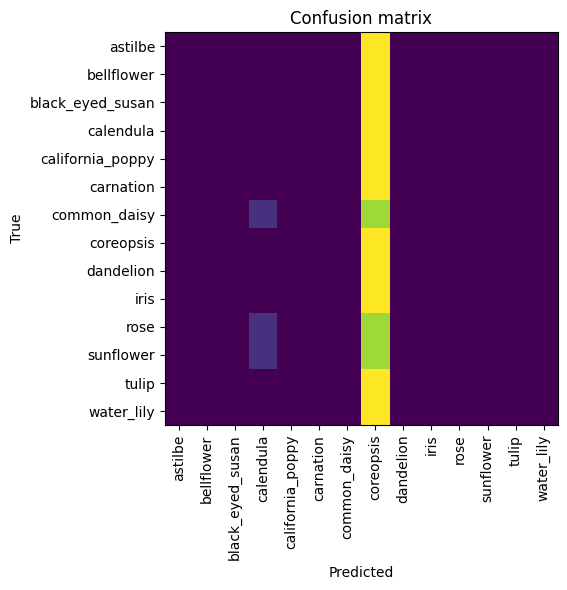

In [14]:

try:
    best_model = model_aug
    print("Meilleur modèle utilisé : model_aug")
except NameError:
    best_model = model_variant
    print("Meilleur modèle utilisé : model_variant")

# Collecter les vraies classes et les prédictions
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)

# Rapport de classification
print("Rapport de classification :")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plot_confusion(cm, class_names)

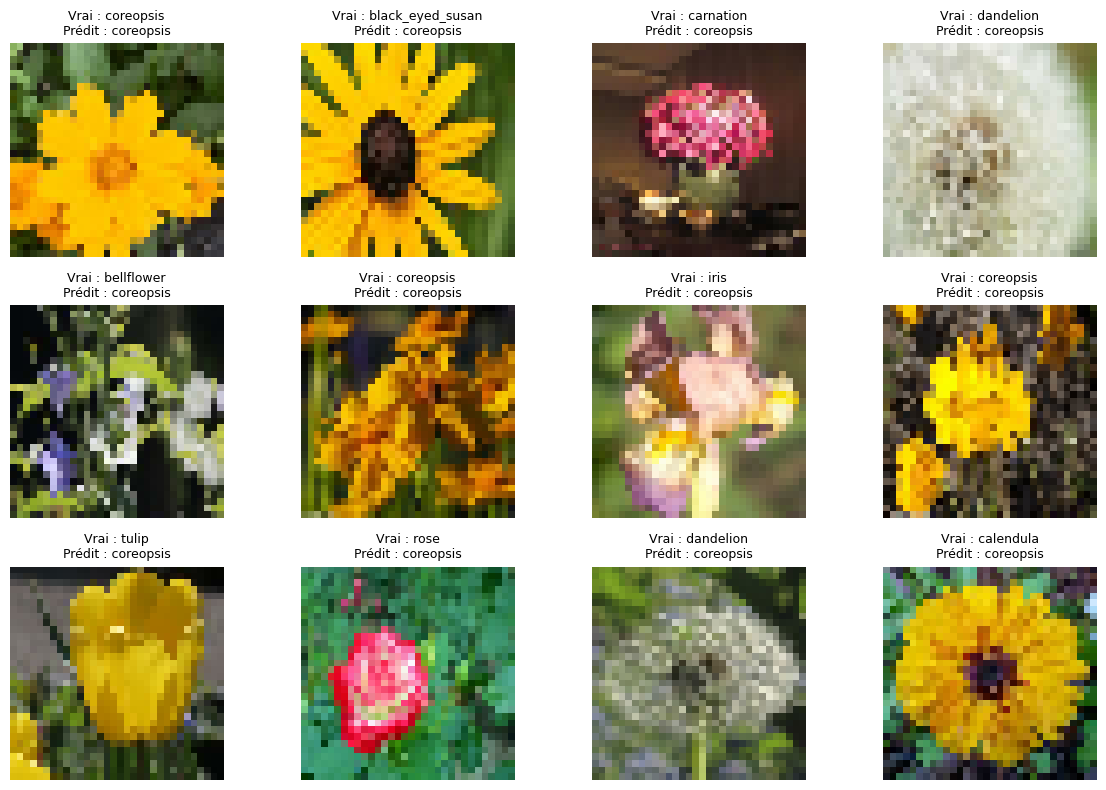

In [15]:


take = 12

imgs, labels = next(iter(val_ds.unbatch().batch(take)))

probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)

plt.figure(figsize=(12, 8))

for i in range(take):
    plt.subplot(3, 4, i + 1)

    image = imgs[i].numpy().astype("uint8")

    true_label = class_names[int(labels[i])]
    pred_label = class_names[int(preds[i])]

    plt.imshow(image)
    plt.title(f"Vrai : {true_label}\nPrédit : {pred_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

Les classes les plus difficiles à classifier sont généralement celles qui ont des couleurs ou des formes proches. Par exemple, certaines fleurs peuvent avoir des pétales similaires ou des couleurs très proches, ce qui peut entraîner des confusions. Les erreurs peuvent aussi venir des arrière-plans, de la luminosité, de l’angle de prise de vue ou du fait que certaines fleurs soient partiellement visibles. Si certaines classes ont peu d’images, le modèle peut aussi moins bien les apprendre. La matrice de confusion permet d’identifier précisément quelles classes sont souvent confondues.

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.


## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [16]:

Path("./data").mkdir(parents=True, exist_ok=True)

best_model.save("./data/flower_cnn_model.keras")

best_model.save("./data/flower_cnn_model.h5")

print("Modèle sauvegardé avec succès dans le dossier ./data/")

Modèle sauvegardé avec succès dans le dossier ./data/


Dans cet exercice, nous avons construit un modèle CNN pour classifier des images de fleurs appartenant à 14 espèces différentes. Nous avons d’abord chargé les données avec image_dataset_from_directory, puis nous avons exploré les classes et visualisé plusieurs images afin de comprendre les difficultés du problème.

Ensuite, nous avons conçu une architecture CNN avec plusieurs couches de convolution, des couches de MaxPooling, Batch Normalization, Dropout et une couche de sortie Softmax. Les couches convolutionnelles permettent d’extraire des caractéristiques visuelles comme les contours, les textures, les couleurs et les formes des pétales.

Nous avons aussi testé différents hyperparamètres comme l’optimiseur, le taux d’apprentissage et l’utilisation de EarlyStopping. L’augmentation des données a permis d’améliorer la généralisation du modèle en créant des variations réalistes des images d’entraînement.

Enfin, nous avons évalué le modèle avec les courbes de précision et de perte, le rapport de classification, la matrice de confusion et la visualisation de quelques prédictions. Cette analyse permet d’identifier les classes que le modèle reconnaît bien et celles qui sont plus difficiles à classifier.